In [1]:
import xarray as xr

file_path = "../data/raw/SST/SST.nc"

ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 455, latitude: 500, longitude: 1200)
Coordinates:
  * time          (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude      (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude     (longitude) float32 5kB 45.03 45.08 45.12 ... 104.9 105.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Se

In [2]:
print(ds.dims)
print(ds.coords)
print(ds.data_vars)

FrozenMappingWarningOnValuesAccess({'time': 455, 'latitude': 500, 'longitude': 1200})
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 5kB 45.03 45.08 45.12 ... 104.9 104.9 105.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB ...


In [3]:
sst = ds["analysed_sst"]

print(sst.attrs)

{'comment': ' OSTIA foundation SST', 'long_name': 'analysed sea surface temperature', 'reference': 'C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017', 'source': 'AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0', 'standard_name': 'sea_surface_foundation_temperature', 'units': 'kelvin', 'valid_max': np.int16(4500), 'valid_min': np.int16(-300)}


In [4]:
print("Minimum:", float(sst.min()))
print("Maximum:", float(sst.max()))
print("Mean:", float(sst.mean()))

Minimum: 273.1399938967079
Maximum: 309.50999308377504
Mean: 301.31971267335393


In [5]:
print("Missing values:", int(sst.isnull().sum()))

Missing values: 136743880


In [6]:
print("Start date:", ds["time"].min().values)
print("End date:", ds["time"].max().values)

Start date: 2025-01-01T00:00:00.000000000
End date: 2026-03-31T00:00:00.000000000


In [7]:
print("Latitude:", float(ds["latitude"].min()), "to", float(ds["latitude"].max()))
print("Longitude:", float(ds["longitude"].min()), "to", float(ds["longitude"].max()))

Latitude: 5.025000095367432 to 29.975000381469727
Longitude: 45.025001525878906 to 104.9749984741211


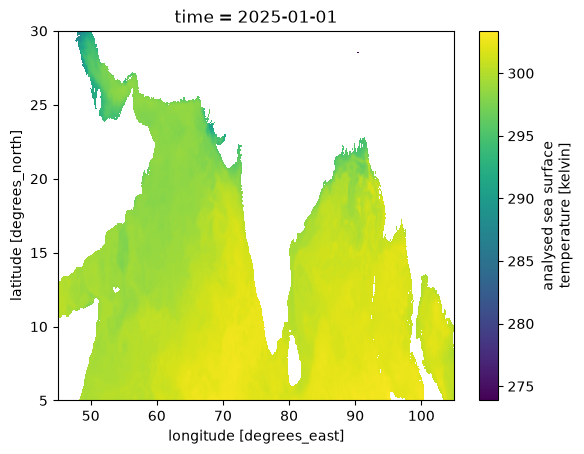

In [8]:
sst_day1 = sst.isel(time=0)

sst_day1.plot()

import matplotlib.pyplot as plt
plt.show()

In [9]:
print(sst.attrs)

print("Minimum:", float(sst.min()))
print("Maximum:", float(sst.max()))
print("Mean:", float(sst.mean()))

print("Missing values:", int(sst.isnull().sum()))

{'comment': ' OSTIA foundation SST', 'long_name': 'analysed sea surface temperature', 'reference': 'C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017', 'source': 'AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0', 'standard_name': 'sea_surface_foundation_temperature', 'units': 'kelvin', 'valid_max': np.int16(4500), 'valid_min': np.int16(-300)}
Minimum: 273.1399938967079
Maximum: 309.50999308377504
Mean: 301.31971267335393
Missing values: 136743880


In [10]:
sst_celsius = sst - 273.15

In [11]:
missing_percentage = (
    sst.isnull().sum() / sst.size
) * 100

print("Total values:", sst.size)
print("Missing values:", int(sst.isnull().sum()))
print("Missing percentage:", float(missing_percentage), "%")

Total values: 273000000
Missing values: 136743880
Missing percentage: 50.08933333333333 %


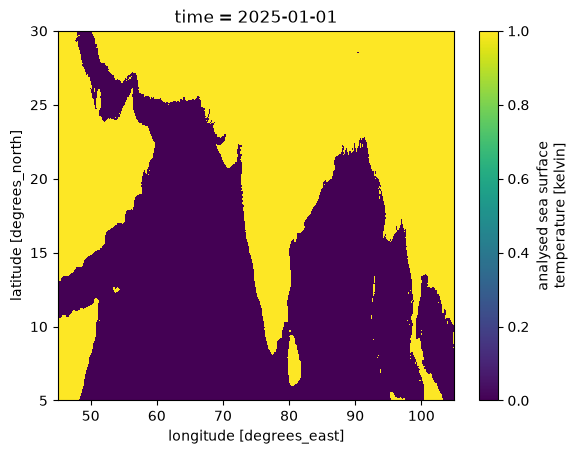

In [12]:
sst_day1 = sst.isel(time=0)

sst_day1.isnull().plot()

import matplotlib.pyplot as plt
plt.show()

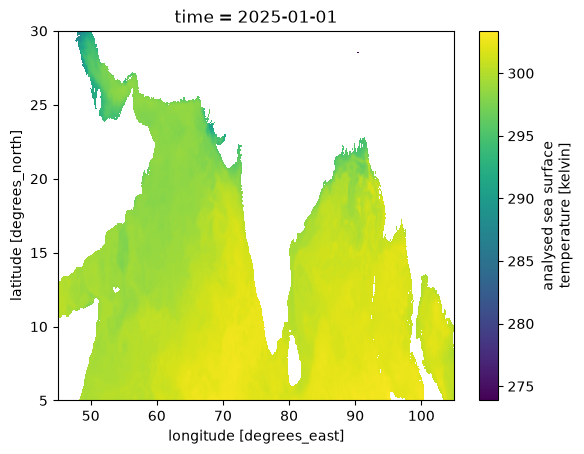

In [13]:
sst_day1.plot()

plt.show()

In [14]:
sst_celsius = sst - 273.15

print(sst_celsius.attrs)
print("Minimum °C:", float(sst_celsius.min()))
print("Maximum °C:", float(sst_celsius.max()))
print("Mean °C:", float(sst_celsius.mean()))

{'comment': ' OSTIA foundation SST', 'long_name': 'analysed sea surface temperature', 'reference': 'C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017', 'source': 'AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0', 'standard_name': 'sea_surface_foundation_temperature', 'units': 'kelvin', 'valid_max': np.int16(4500), 'valid_min': np.int16(-300)}
Minimum °C: -0.010006103292084845
Maximum °C: 36.359993083775066
Mean °C: 28.1697126733539


In [15]:
sst_celsius = sst - 273.15

print("Minimum °C:", float(sst_celsius.min()))
print("Maximum °C:", float(sst_celsius.max()))
print("Mean °C:", float(sst_celsius.mean()))

print("\nValues below -2°C:",
      int((sst_celsius < -2).sum().values))

print("Values above 40°C:",
      int((sst_celsius > 40).sum().values))

Minimum °C: -0.010006103292084845
Maximum °C: 36.359993083775066
Mean °C: 28.1697126733539

Values below -2°C: 0
Values above 40°C: 0


In [16]:
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 455, latitude: 500, longitude: 1200)
Coordinates:
  * time          (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude      (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude     (longitude) float32 5kB 45.03 45.08 45.12 ... 104.9 105.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 2GB nan nan ... nan nan
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                     

In [17]:
print("Actual first time:", ds.time.values[0])
print("Actual last time:", ds.time.values[-1])

print("Metadata start:", ds.attrs.get("time_coverage_start"))
print("Metadata end:", ds.attrs.get("time_coverage_end"))

Actual first time: 2025-01-01T00:00:00.000000000
Actual last time: 2026-03-31T00:00:00.000000000
Metadata start: 19811001T000000Z
Metadata end: 19811002T000000Z


In [18]:
print(ds["analysed_sst"].encoding)

{'dtype': dtype('int16'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SST\\SST.nc', 'original_shape': (455, 500, 1200), '_FillValue': np.int16(-32768), 'scale_factor': np.float64(0.009999999776482582), 'add_offset': np.float64(273.1499938964844), 'coordinates': 'lon lat'}


In [19]:
print(ds["analysed_sst"].dtype)

float64


In [21]:
print("Actual first time:", ds.time.values[0])
print("Actual last time:", ds.time.values[-1])

print("Metadata start:", ds.attrs.get("time_coverage_start"))
print("Metadata end:", ds.attrs.get("time_coverage_end"))

print(ds["analysed_sst"].encoding)
print(ds["analysed_sst"].dtype)

Actual first time: 2025-01-01T00:00:00.000000000
Actual last time: 2026-03-31T00:00:00.000000000
Metadata start: 19811001T000000Z
Metadata end: 19811002T000000Z
{'dtype': dtype('int16'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SST\\SST.nc', 'original_shape': (455, 500, 1200), '_FillValue': np.int16(-32768), 'scale_factor': np.float64(0.009999999776482582), 'add_offset': np.float64(273.1499938964844), 'coordinates': 'lon lat'}
float64


In [22]:
import xarray as xr

processed_file = "../data/processed/SST/SST_processed.nc"

ds_sst = xr.open_dataset(processed_file)

print(ds_sst)

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 455, latitude: 500, longitude: 1200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 5kB 45.03 45.08 45.12 ... 104.9 104.9 105.0
Data variables:
    sst        (time, latitude, longitude) float32 1GB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          2026-03-31T00:00:00
    time_coverage_start:        2025-01-01T00:00:00
    title:                      Global SST & Sea I

In [23]:
sst_processed = ds_sst["sst"]

print(sst_processed.attrs)

print("Minimum:", float(sst_processed.min()))
print("Maximum:", float(sst_processed.max()))
print("Mean:", float(sst_processed.mean()))

{'comment': ' OSTIA foundation SST', 'long_name': 'analysed sea surface temperature', 'reference': 'C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017', 'source': 'AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0', 'standard_name': 'sea_surface_foundation_temperature', 'units': 'degree_Celsius', 'description': 'Sea surface temperature converted from Kelvin to Celsius'}
Minimum: -0.010006103664636612
Maximum: 36.35999298095703
Mean: 28.169713973999023


In [24]:
print("Start:", ds_sst.time.values[0])
print("End:", ds_sst.time.values[-1])

Start: 2025-01-01T00:00:00.000000000
End: 2026-03-31T00:00:00.000000000


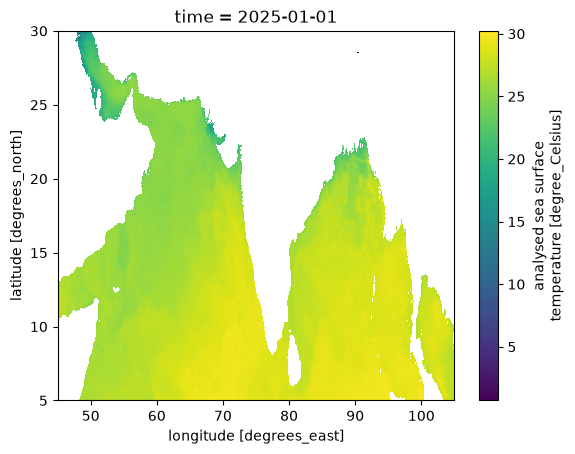

In [25]:
sst_processed.isel(time=0).plot()

import matplotlib.pyplot as plt
plt.show()

In [26]:
print(ds_sst)
print(ds_sst["sst"].attrs)

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 455, latitude: 500, longitude: 1200)
Coordinates:
  * time       (time) datetime64[ns] 4kB 2025-01-01 2025-01-02 ... 2026-03-31
  * latitude   (latitude) float32 2kB 5.025 5.075 5.125 ... 29.88 29.92 29.98
  * longitude  (longitude) float32 5kB 45.03 45.08 45.12 ... 104.9 104.9 105.0
Data variables:
    sst        (time, latitude, longitude) float32 1GB nan nan nan ... nan nan
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          2026-03-31T00:00:00
    time_coverage_start:        2025-01-01T00:00:00
    title:                    